# Credit Risk — Notebook 01 · Data Engineering & Feature Store

| | |
|---|---|
| **Auteur** | Tangara Abdoulaye – Quantitative Modeling |
| **Statut** | Production-Ready |
| **Dernière révision** | 2025 |
| **Référentiel** | IFRS 9 · Bâle II/III · SR 11-7 |

---

## Objectif

Ce notebook constitue le **premier maillon de la chaîne de modélisation du risque de crédit**. Il prend en charge :

1. **Ingestion & audit qualité** — chargement, typage, inventaire des données manquantes  
2. **Détection & traitement des outliers** — méthode IQR adaptative sur toutes les variables financières  
3. **Imputation supervisée** — stratégie différenciée selon la distribution et le taux de missing  
4. **Création de la variable cible PD** — binarisation conforme Bâle II (90 DPD)  
5. **Feature engineering** — interactions, ratios financiers, indicateurs de stress  
6. **Exclusion des variables contaminantes** — data leakage, informations post-défaut, données sensibles  
7. **Export du Feature Store** — dataset propre versionné pour les notebooks aval

> **Convention de nommage** : toutes les colonnes créées dans ce notebook sont préfixées `fe_` (feature-engineered) pour traçabilité.

---

## 0 · Environnement & Configuration

In [ ]:
# =============================================================================
# 0.1 IMPORTS
# =============================================================================
import os
import warnings
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from google.colab import drive

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger(__name__)
np.random.seed(42)

# =============================================================================
# 0.2 STYLE GRAPHIQUE — Morgan Stanley palette (Bleu marine / Gris)
# =============================================================================
MS_BLUE   = '#003087'
MS_LIGHT  = '#6699CC'
MS_GREY   = '#666666'
MS_RED    = '#CC0000'
MS_GREEN  = '#006633'
MS_AMBER  = '#CC8800'

plt.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.edgecolor'      : '#CCCCCC',
    'axes.linewidth'      : 0.8,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.grid'           : True,
    'grid.color'          : '#EEEEEE',
    'grid.linewidth'      : 0.5,
    'font.family'         : 'sans-serif',
    'font.size'           : 11,
    'axes.titlesize'      : 13,
    'axes.titleweight'    : 'bold',
    'axes.labelsize'      : 11,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.frameon'      : False,
})

# =============================================================================
# 0.3 CHEMINS
# =============================================================================
drive.mount('/content/drive', force_remount=True)

BASE_PATH    = Path('/content/drive/MyDrive/Credit_Risk_PD_LGD_EAD')
RAW_PATH     = BASE_PATH / 'DATA' / 'RAW'
INTERIM_PATH = BASE_PATH / 'DATA' / 'INTERIM'
REPORTS_PATH = BASE_PATH / 'REPORTS'

for p in [INTERIM_PATH, REPORTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

log.info('Environnement initialisé | Base: %s', BASE_PATH)

Mounted at /content/drive


## 1 · Ingestion & Audit Qualité

In [ ]:
# =============================================================================
# 1.1 CHARGEMENT OPTIMISÉ MÉMOIRE
# =============================================================================
log.info('Chargement du dataset brut...')
df_raw = pd.read_csv(RAW_PATH / 'loan.csv', low_memory=False)

# Typage initial — réduction empreinte mémoire
CAT_COLS = [
    'grade', 'sub_grade', 'emp_title', 'home_ownership', 'purpose', 'term',
    'verification_status', 'loan_status', 'pymnt_plan', 'initial_list_status',
    'application_type', 'hardship_flag', 'addr_state', 'disbursement_method',
    'debt_settlement_flag'
]
DATE_COLS = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

for col in CAT_COLS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype('category')

for col in DATE_COLS:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], format='%b-%Y', errors='coerce')

# emp_length — conversion numérique propre
df_raw['emp_length'] = (
    df_raw['emp_length']
    .str.replace(r'[^0-9]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
    .fillna(0)
)

# Float64 → Float32 (gain ~50% mémoire numérique)
num_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns
df_raw[num_cols] = df_raw[num_cols].astype(np.float32)

log.info('Dataset chargé : %s lignes × %s colonnes', *df_raw.shape)

In [ ]:
# =============================================================================
# 1.2 RAPPORT DE QUALITÉ DES DONNÉES
# =============================================================================
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Génère un rapport de qualité complet pour chaque colonne.
    Retourne un DataFrame trié par taux de missing décroissant.
    """
    n = len(df)
    report = pd.DataFrame({
        'dtype'         : df.dtypes,
        'n_missing'     : df.isnull().sum(),
        'pct_missing'   : df.isnull().mean() * 100,
        'n_unique'      : df.nunique(),
        'pct_unique'    : df.nunique() / n * 100,
    })
    # Ajouter skewness pour les numériques
    skew = df.select_dtypes(include='number').skew()
    report['skewness'] = skew

    return report.sort_values('pct_missing', ascending=False)

dq = data_quality_report(df_raw)

# Affichage — colonnes avec missing seulement
dq_missing = dq[dq['n_missing'] > 0].copy()
print(f'Colonnes avec valeurs manquantes : {len(dq_missing)} / {len(dq)}')
print(f'Taux global de complétude       : {(1 - df_raw.isnull().sum().sum() / df_raw.size):.2%}')
display(dq_missing.head(30))

Colonnes avec valeurs manquantes : 112 / 145
Taux global de complétude       : 66.89%


,dtype,n_missing,pct_missing,n_unique,pct_unique,skewness
id,float32,2260668,100.000000,0,0.000000,NaN
member_id,float32,2260668,100.000000,0,0.000000,NaN
url,float32,2260668,100.000000,0,0.000000,NaN
orig_projected_additional_accrued_interest,float32,2252242,99.627278,7313,0.323488,1.599409
hardship_amount,float32,2250055,99.530537,8950,0.395901,1.606077
hardship_dpd,float32,2250055,99.530537,34,0.001504,-0.124221
hardship_loan_status,object,2250055,99.530537,5,0.000221,NaN
deferral_term,float32,2250055,99.530537,1,0.000044,0.000000
hardship_end_date,object,2250055,99.530537,27,0.001194,NaN
hardship_status,object,2250055,99.530537,3,0.000133,NaN


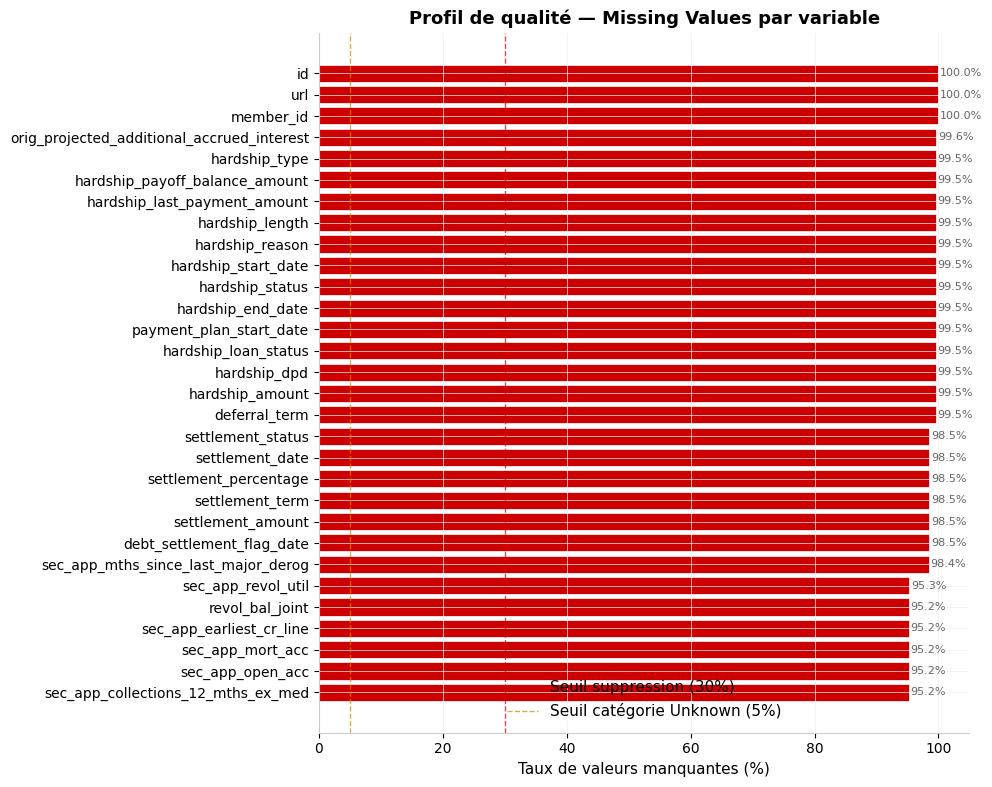

In [ ]:
# =============================================================================
# 1.3 VISUALISATION DU PROFIL DE MISSING VALUES
# =============================================================================
missing_top = dq_missing[dq_missing['pct_missing'] > 0].sort_values('pct_missing', ascending=True)
missing_top = missing_top.tail(30)  # Top 30

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_top.index, missing_top['pct_missing'],
               color=[MS_RED if v > 30 else MS_AMBER if v > 5 else MS_LIGHT
                      for v in missing_top['pct_missing']],
               edgecolor='white', linewidth=0.5)

ax.axvline(30, color=MS_RED,   linestyle='--', linewidth=1, label='Seuil suppression (30%)', alpha=0.7)
ax.axvline(5,  color=MS_AMBER, linestyle='--', linewidth=1, label='Seuil catégorie Unknown (5%)', alpha=0.7)

for bar, val in zip(bars, missing_top['pct_missing']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8, color=MS_GREY)

ax.set_xlabel('Taux de valeurs manquantes (%)')
ax.set_title('Profil de qualité — Missing Values par variable')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'missing_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Exclusion des Variables Contaminantes

In [ ]:
# =============================================================================
# 2.1 TAXONOMIE DES VARIABLES À EXCLURE
#
# RÈGLE CARDINALE : toute information post-octroi ou révélatrice de l'état
# de défaut (statut de recouvrement, paiements effectués, etc.) constitue
# un data leakage et invalide le modèle en production.
# =============================================================================
EXCLUDE = {
    'Identifiants_techniques': [
        'id', 'member_id', 'url', 'desc'
    ],
    'Dates_futures': [
        'next_pymnt_d', 'hardship_start_date', 'hardship_end_date',
        'debt_settlement_flag_date', 'settlement_date', 'sec_app_earliest_cr_line'
    ],
    'Informations_sensibles': [
        'emp_title',  # RGPD / égalité de traitement
    ],
    'Post_defaut_leakage': [
        # Statut de recouvrement (connu uniquement APRÈS défaut)
        'settlement_status', 'settlement_amount', 'settlement_percentage', 'settlement_term',
        'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term',
        'hardship_amount', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
        'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
        'hardship_last_payment_amount',
        # Variables de comportement post-origination (SICR / observation window)
        'mths_since_last_major_derog', 'mths_since_recent_bc_dlq',
        'mths_since_recent_revol_delinq',
        # Données de co-emprunteur (disponibles seulement pour joint applications)
        'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'revol_bal_joint',
        'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc',
        'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts',
        'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
        'sec_app_mths_since_last_major_derog',
        # Variables comportementales haute fréquence (forward-looking)
        'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
        'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
        'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
    ]
}

exclude_flat = set(v for grp in EXCLUDE.values() for v in grp)
exclude_present = [c for c in exclude_flat if c in df_raw.columns]

log.info('Variables exclues : %d / %d présentes dans le dataset', len(exclude_present), len(exclude_flat))

df = df_raw.drop(columns=exclude_present, errors='ignore').copy()
log.info('Dataset après exclusion : %d colonnes', df.shape[1])

## 3 · Imputation des Valeurs Manquantes

In [ ]:
# =============================================================================
# 3.1 STRATÉGIE D'IMPUTATION — Logique décisionnelle documentée
#
# Seuil > 30% → Suppression de la colonne (signal trop faible)
# 5% < missing ≤ 30% → Catégorie 'Unknown' (catégoriel) ou indicateur de missing
# missing ≤ 5% → Médiane (|skew| > 1) ou Moyenne
# =============================================================================
DROP_THRESHOLD    = 0.30
UNKNOWN_THRESHOLD = 0.05

imputation_log = []
cols_dropped   = []

def impute_numerical(df_: pd.DataFrame) -> pd.DataFrame:
    """Imputation des variables numériques avec stratégie adaptative."""
    df_out = df_.copy()
    num_cols_ = df_out.select_dtypes(include='number').columns

    for col in num_cols_:
        pct_miss = df_out[col].isnull().mean()
        if pct_miss == 0:
            continue

        if pct_miss > DROP_THRESHOLD:
            df_out.drop(columns=[col], inplace=True)
            cols_dropped.append(col)
            imputation_log.append({'col': col, 'strategy': 'DROP', 'pct_miss': pct_miss})
            continue

        # Ajouter un indicateur binaire de missing (informativité potentielle)
        if pct_miss > UNKNOWN_THRESHOLD:
            df_out[f'fe_missing_{col}'] = df_out[col].isnull().astype(np.int8)

        skew = df_out[col].skew()
        if abs(skew) > 1:
            fill_val = df_out[col].median()
            strategy = f'median (skew={skew:.2f})'
        else:
            fill_val = df_out[col].mean()
            strategy = f'mean (skew={skew:.2f})'

        df_out[col] = df_out[col].fillna(fill_val)
        imputation_log.append({'col': col, 'strategy': strategy, 'pct_miss': pct_miss, 'fill_val': fill_val})

    return df_out


def impute_categorical(df_: pd.DataFrame) -> pd.DataFrame:
    """Imputation des variables catégorielles."""
    df_out = df_.copy()
    cat_cols_ = df_out.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols_:
        pct_miss = df_out[col].isnull().mean()
        if pct_miss == 0:
            continue

        if pct_miss > DROP_THRESHOLD:
            df_out.drop(columns=[col], inplace=True)
            cols_dropped.append(col)
            imputation_log.append({'col': col, 'strategy': 'DROP', 'pct_miss': pct_miss})
            continue

        if pct_miss > UNKNOWN_THRESHOLD:
            # Créer la catégorie 'Unknown' proprement
            if hasattr(df_out[col], 'cat'):
                df_out[col] = df_out[col].cat.add_categories(['Unknown'])
            df_out[col] = df_out[col].fillna('Unknown')
            strategy = 'Unknown'
        else:
            mode_val = df_out[col].mode()[0]
            df_out[col] = df_out[col].fillna(mode_val)
            strategy = f'mode={mode_val}'

        imputation_log.append({'col': col, 'strategy': strategy, 'pct_miss': pct_miss})

    return df_out


df = impute_numerical(df)
df = impute_categorical(df)

# Imputation résiduelle (dates, etc.)
residual = [c for c in df.columns if df[c].isnull().sum() > 0]
for col in residual:
    if df[col].dtype in ['datetime64[ns]', 'object', 'category']:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Rapport final
imp_df = pd.DataFrame(imputation_log)
remaining_miss = df.isnull().sum().sum()

print(f'Colonnes supprimées (> {DROP_THRESHOLD:.0%} missing) : {len(cols_dropped)}')
print(f'Indicateurs de missing créés (fe_missing_*)        : {sum(1 for c in df.columns if c.startswith("fe_missing_"))}')
print(f'Valeurs manquantes résiduelles                     : {remaining_miss}')
assert remaining_miss == 0, 'Des valeurs manquantes subsistent — vérifier le pipeline.'
print('✔ Zéro valeur manquante — dataset complet.')

Colonnes supprimées (> 30% missing) : 3
Indicateurs de missing créés (fe_missing_*)        : 3
Valeurs manquantes résiduelles                     : 0
✔ Zéro valeur manquante — dataset complet.


## 4 · Traitement des Outliers

In [ ]:
# =============================================================================
# 4.1 WINSORISATION — Méthode IQR adaptative
#
# Appliquée à TOUTES les variables numériques financières, pas seulement 5.
# Multiplier = 3.0 pour conserver les cas extrêmes légitimes (fraude, stress).
# Un flag binaire est créé pour chaque variable winsorizée.
# =============================================================================
WINSOR_MULTIPLIER = 3.0  # 1.5 trop agressif pour données financières

FINANCIAL_VARS = [
    'annual_inc', 'dti', 'revol_util', 'tot_cur_bal', 'total_rev_hi_lim',
    'loan_amnt', 'funded_amnt', 'installment', 'revol_bal',
    'out_prncp', 'total_pymnt', 'total_rec_prncp', 'total_rec_int',
    'recoveries', 'collection_recovery_fee', 'inq_last_6mths',
    'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies', 'open_acc', 'total_acc'
]

outlier_report = []

def winsorize_col(series: pd.Series, mult: float = WINSOR_MULTIPLIER):
    """Retourne (série winsorizée, borne_inf, borne_sup, pct_affecté)."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - mult * IQR, Q3 + mult * IQR
    winsorized = series.clip(lower=lo, upper=hi)
    pct = ((series < lo) | (series > hi)).mean()
    return winsorized, lo, hi, pct

for col in FINANCIAL_VARS:
    if col not in df.columns:
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue

    winsorized, lo, hi, pct = winsorize_col(df[col])

    if pct > 0:
        df[f'fe_outlier_{col}'] = ((df[col] < lo) | (df[col] > hi)).astype(np.int8)
        df[col] = winsorized
        outlier_report.append({'variable': col, 'pct_winsorized': pct,
                               'lower_bound': lo, 'upper_bound': hi})

out_df = pd.DataFrame(outlier_report).sort_values('pct_winsorized', ascending=False)
print(f'Variables winsorizées : {len(out_df)}')
display(out_df.head(15))

Variables winsorizées : 18


,variable,pct_winsorized,lower_bound,upper_bound
13,delinq_2yrs,0.186463,0.000000,0.000000
14,pub_rec,0.158308,0.000000,0.000000
15,pub_rec_bankruptcies,0.120283,0.000000,0.000000
10,recoveries,0.078517,0.000000,0.000000
11,collection_recovery_fee,0.074792,0.000000,0.000000
7,out_prncp,0.026355,-20137.897339,26850.529785
6,revol_bal,0.023764,-36938.000000,63134.000000
9,total_rec_int,0.023736,-6382.219971,10128.049927
4,total_rev_hi_lim,0.020934,-66900.000000,124200.000000
0,annual_inc,0.016168,-95000.000000,234000.000000


## 5 · Variable Cible & Feature Engineering

In [ ]:
# =============================================================================
# 5.1 VARIABLE CIBLE PD — Définition conforme Bâle II (Article 178)
#
# Un emprunteur est en défaut si :
# (a) retard > 90 jours sur une obligation matérielle, OU
# (b) la banque estime improbable le remboursement sans recours.
# Dans ce dataset LendingClub, 'Late 31-120 days' et 'Charged Off'
# constituent les proxies les plus proches.
# =============================================================================
DEFAULT_STATUSES = frozenset([
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
])

df['target_default'] = df['loan_status'].isin(DEFAULT_STATUSES).astype(np.int8)

default_rate = df['target_default'].mean()
n_defaults   = df['target_default'].sum()

log.info('Taux de défaut : %.2f%% (%d cas / %d)', default_rate*100, n_defaults, len(df))

In [ ]:
# =============================================================================
# 5.2 FEATURE ENGINEERING — Ratios financiers & indicateurs de stress
# =============================================================================

# --- Ratios de levier & capacité de remboursement ---
df['fe_dti_income_ratio']   = df['dti'] * df['loan_amnt'] / (df['annual_inc'] + 1)
df['fe_installment_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
df['fe_loan_to_income']     = df['loan_amnt'] / (df['annual_inc'] + 1)

# --- Utilisation du crédit renouvelable ---
df['fe_revol_stress'] = df['revol_util'] * df['dti']   # composite risque
df['fe_revol_burden'] = df['revol_bal']  / (df['annual_inc'] + 1)

# --- Historique crédit ---
df['fe_delinquency_ratio'] = (df['delinq_2yrs'] + df['pub_rec']) / (df['total_acc'] + 1)
df['fe_inq_per_account']   = df['inq_last_6mths'] / (df['open_acc'] + 1)

# --- Ancienneté crédit (en années depuis l'émission) ---
if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
    df['fe_credit_age_years'] = (
        (df['issue_d'] - df['earliest_cr_line'])
        .dt.days / 365.25
    ).clip(0, 50).astype(np.float32)

# --- Taux d'intérêt ---
if 'int_rate' in df.columns:
    df['fe_int_rate_stress'] = df['int_rate'] * df['dti']

# Clipping des ratios créés
fe_cols = [c for c in df.columns if c.startswith('fe_') and not c.startswith('fe_missing') and not c.startswith('fe_outlier')]
for col in fe_cols:
    p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(p1, p99).astype(np.float32)

log.info('Features créées (fe_*) : %d', len(fe_cols))
print(fe_cols)

['fe_dti_income_ratio', 'fe_installment_income', 'fe_loan_to_income', 'fe_revol_stress', 'fe_revol_burden', 'fe_delinquency_ratio', 'fe_inq_per_account', 'fe_credit_age_years', 'fe_int_rate_stress']


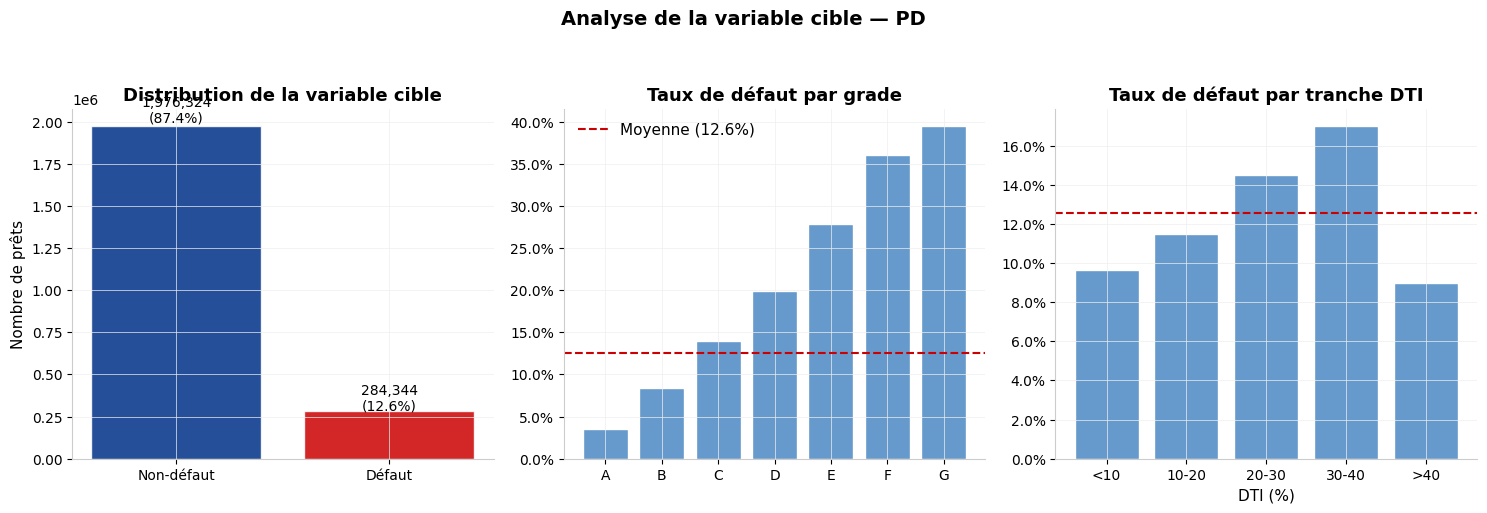

In [ ]:
# =============================================================================
# 5.3 VISUALISATION — Distribution du taux de défaut par segment
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribution globale
counts = df['target_default'].value_counts()
axes[0].bar(['Non-défaut', 'Défaut'], counts.values,
            color=[MS_BLUE, MS_RED], alpha=0.85, edgecolor='white')
for i, (v, lbl) in enumerate(zip(counts.values, ['Non-défaut', 'Défaut'])):
    axes[0].text(i, v * 1.01, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de prêts')

# 2. Taux de défaut par grade
if 'grade' in df.columns:
    dr_grade = df.groupby('grade', observed=True)['target_default'].mean().sort_index()
    axes[1].bar(dr_grade.index.astype(str), dr_grade.values * 100, color=MS_LIGHT, edgecolor='white')
    axes[1].axhline(default_rate * 100, color=MS_RED, linestyle='--', linewidth=1.5, label=f'Moyenne ({default_rate:.1%})')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1].set_title('Taux de défaut par grade')
    axes[1].legend()

# 3. Taux de défaut par tranche de DTI
if 'dti' in df.columns:
    df['_dti_bin'] = pd.cut(df['dti'], bins=[0, 10, 20, 30, 40, 100], labels=['<10', '10-20', '20-30', '30-40', '>40'])
    dr_dti = df.groupby('_dti_bin', observed=True)['target_default'].mean()
    axes[2].bar(dr_dti.index.astype(str), dr_dti.values * 100, color=MS_LIGHT, edgecolor='white')
    axes[2].axhline(default_rate * 100, color=MS_RED, linestyle='--', linewidth=1.5)
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[2].set_title('Taux de défaut par tranche DTI')
    axes[2].set_xlabel('DTI (%)')
    df.drop(columns=['_dti_bin'], inplace=True)

plt.suptitle('Analyse de la variable cible — PD', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Sélection & Validation des Features

In [ ]:
# =============================================================================
# 6.1 FEATURES SÉLECTIONNÉES — Catégorisées par bloc de risque
# =============================================================================
FEATURE_BLOCKS = {
    'Caractéristiques_prêt': [
        'loan_amnt', 'term', 'int_rate', 'installment', 'purpose', 'grade'
    ],
    'Profil_emprunteur': [
        'annual_inc', 'dti', 'emp_length', 'home_ownership', 'verification_status'
    ],
    'Utilisation_crédit': [
        'revol_util', 'revol_bal', 'open_acc', 'total_acc'
    ],
    'Historique_crédit': [
        'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies',
        'mths_since_recent_inq', 'mths_since_last_delinq'
    ],
    'Features_engineered': [
        'fe_dti_income_ratio', 'fe_installment_income', 'fe_loan_to_income',
        'fe_revol_stress', 'fe_revol_burden', 'fe_delinquency_ratio',
        'fe_inq_per_account', 'fe_credit_age_years', 'fe_int_rate_stress'
    ]
}

# Filtrer les features présentes dans le dataset
SELECTED_FEATURES = [
    f for grp in FEATURE_BLOCKS.values()
    for f in grp if f in df.columns
]

# Ajouter les indicateurs de missing et d'outliers créés
SELECTED_FEATURES += [c for c in df.columns if c.startswith('fe_missing_') or c.startswith('fe_outlier_')]

print(f'Features sélectionnées : {len(SELECTED_FEATURES)}')
for block, feats in FEATURE_BLOCKS.items():
    present = [f for f in feats if f in df.columns]
    print(f'  {block:<35} : {len(present)} features')

Features sélectionnées : 50
  Caractéristiques_prêt               : 6 features
  Profil_emprunteur                   : 5 features
  Utilisation_crédit                  : 4 features
  Historique_crédit                   : 5 features
  Features_engineered                 : 9 features


In [ ]:
# =============================================================================
# 6.2 VALIDATION — Vérification de l'absence de leakage résiduel
# =============================================================================
# Colonnes qui ne doivent JAMAIS apparaître dans les features
LEAKAGE_SENTINEL = {
    'loan_status', 'target_default',
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt'
}

leakage_found = LEAKAGE_SENTINEL & set(SELECTED_FEATURES)
if leakage_found:
    raise ValueError(f'⛔ LEAKAGE DÉTECTÉ : {leakage_found}')
else:
    print('✔ Aucun leakage détecté dans les features sélectionnées.')

# Vérification des types
X_check = df[SELECTED_FEATURES]
assert X_check.isnull().sum().sum() == 0, 'Des NaN subsistent dans les features.'
print(f'✔ Zéro NaN dans les {len(SELECTED_FEATURES)} features.')

✔ Aucun leakage détecté dans les features sélectionnées.
✔ Zéro NaN dans les 50 features.


## 7 · Export du Feature Store

In [ ]:
# =============================================================================
# 7.1 EXPORT — Feature Store versionné
# =============================================================================
VERSION = datetime.now().strftime('%Y%m%d')

# Dataset complet nettoyé (pour LGD/EAD qui ont besoin de out_prncp, recoveries, etc.)
df_full_clean = df.copy()

# Dataset modèle PD — features + cible uniquement
df_pd_store = df[list(np.unique(SELECTED_FEATURES + ['target_default', 'loan_status', 'loan_amnt', 'int_rate']))].copy()

# Sauvegarde
full_path = INTERIM_PATH / f'loan_clean_full_{VERSION}.parquet'
pd_path   = INTERIM_PATH / f'loan_pd_features_{VERSION}.parquet'

df_full_clean.to_parquet(full_path, index=False)
df_pd_store.to_parquet(pd_path, index=False)

# Sauvegarde CSV de compatibilité
df_full_clean.to_csv(INTERIM_PATH / 'loan_cleaned.csv', index=False)

log.info('Feature Store exporté')
log.info('  Full dataset : %s (%s MB)', full_path.name, full_path.stat().st_size // 1e6)
log.info('  PD features  : %s (%s MB)', pd_path.name, pd_path.stat().st_size // 1e6)

In [ ]:
# =============================================================================
# 7.2 CARTE DE SYNTHÈSE
# =============================================================================
summary = {
    'Observations'         : f'{len(df):,}',
    'Features sélectionnées': len(SELECTED_FEATURES),
    'Colonnes supprimées'  : len(cols_dropped),
    'Taux de défaut'       : f'{default_rate:.2%}',
    'Défauts (n)'          : f'{int(n_defaults):,}',
    'Features engineered'  : len([c for c in SELECTED_FEATURES if c.startswith('fe_')]),
    'Variables winsorizées': len(out_df),
    'Version export'       : VERSION,
}

print('\n' + '='*55)
print('  FEATURE STORE — RÉSUMÉ PIPELINE')
print('='*55)
for k, v in summary.items():
    print(f'  {k:<30} : {v}')
print('='*55)
print('  → Notebook 02 (EDA) et 03 (Modélisation) prêts.')


  FEATURE STORE — RÉSUMÉ PIPELINE
  Observations                   : 2,260,668
  Features sélectionnées         : 50
  Colonnes supprimées            : 3
  Taux de défaut                 : 12.58%
  Défauts (n)                    : 284,344
  Features engineered            : 30
  Variables winsorizées          : 18
  Version export                 : 20260511
  → Notebook 02 (EDA) et 03 (Modélisation) prêts.
